# CNeuroMod QA — per-region atlas tSNR

Raincloud distributions of per-run, per-region tSNR extracted from the shared MNI152NLin2009cAsym combined atlas (Schaefer2018 cortex / Yeo-7 networks, Tian S3 subcortex, Nettekoven cerebellum — see `analysis/atlas_labels.py`), read from `output_data/tables/atlas_tsnr/`. Figures are written to `output_data/figures/atlas_tsnr/`.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt  # noqa: F401
import numpy as np  # noqa: F401
import pandas as pd
import seaborn as sns

try:
    import ptitprince
    HAS_PTITPRINCE = True
except Exception:
    HAS_PTITPRINCE = False

# The shared house style lives next to the notebooks (nbconvert runs with
# notebooks/ as the cwd, so `analysis` is not importable here); the sys.path
# line makes the import work when the notebook is opened from the repo root too.
# GROUP_COLORS is the fixed Yeo-7 + Cerebellum/Central domain palette that links
# each violin below to its same-coloured glass-brain map (see figure_style).
sys.path.insert(0, str(Path.cwd()))
import figure_style  # noqa: E402
from figure_style import GRID, GROUP_COLORS, HUE, INK, MUTED, style_axes  # noqa: E402,F401

# Paths are provided by `invoke run-notebooks` as environment variables.
# Figures go in output_data/figures/{FIG_NAME}/ (also the notebook's "already
# ran" sentinel); the per-region tables live in output_data/tables/atlas_tsnr/.
FIG_NAME = "atlas_tsnr"
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data"))
FIG_DIR = OUTPUT_DIR / "figures" / FIG_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_tables(subdir):
    """Concatenate every non-empty TSV in output_data/<subdir>/."""
    frames = []
    for path in sorted((OUTPUT_DIR / subdir).glob("*.tsv")):
        try:
            frame = pd.read_csv(path, sep="\t")
        except (pd.errors.EmptyDataError, OSError):
            continue
        if not frame.empty:
            frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def panel(name, default, **kwargs):
    """A figure sized to the box the montage places `name` in (see figure_style)."""
    return plt.subplots(
        figsize=figure_style.panel_size(f"{FIG_NAME}/{name}", default),
        layout="constrained", **kwargs)


In [2]:
def raincloud(data, x, y, ax, color=None, palette=None, ascending=True):
    """Half-violin + jittered strip in a single recessive hue (no boxplot).

    A full RainCloud stacks a half-violin, a boxplot, and a strip; we drop the
    box and compose the two remaining layers directly (ptitprince exposes
    `half_violinplot` and `stripplot`), with a seaborn fallback. The category is
    already named on the x-axis, so colour would normally carry no extra
    information and a single recessive hue is used; pass `palette` (a
    `category -> hex` mapping) when colour needs to carry identity instead
    (e.g. linking each violin to a same-colored map in another panel) — only
    the violin fill uses it, strip points stay a neutral/dark recessive mark
    so they still read against light fills.

    Mark sizes are set for the ~1-inch-tall box this panel is placed in on the
    montage: at page scale, larger dots merge into a solid blob.

    Clouds are scaled to a common maximum width (`scale="width"`) rather than a
    common area: the region groups differ hugely in spread — "Central
    structures" is tight enough that under area scaling its density peak alone
    spilled across the neighbouring category — and each cloud is read for its
    own shape, not against its neighbours' mass. `VIOLIN_WIDTH` then slightly exceeds one
    category slot on purpose: only the left half of each violin is drawn, so a
    cloud spans `VIOLIN_WIDTH / 2` and stays clear of the neighbouring
    category's strip (offset +.2 from its own centre).

    Categories are ordered along the x-axis by their median `y`: `ascending=True`
    (default) runs least-to-most left-to-right; pass `ascending=False` for tSNR,
    where higher is better, so the best sits on the left and the worst on the
    right (same convention as qc_measures.ipynb)."""
    VIOLIN_WIDTH = 1.2
    color = HUE if color is None else color
    data = data[[x, y]].dropna()
    if data.empty:
        ax.set_title(f"no data for {y}")
        return ax
    order = (data.groupby(x)[y].median()
                 .sort_values(ascending=ascending).index.tolist())
    n = max(data[x].nunique(), 1)
    fill_colors = [palette[c] for c in order] if palette is not None else [color] * n
    if HAS_PTITPRINCE:
        try:
            ptitprince.half_violinplot(x=x, y=y, data=data, order=order,
                                       palette=fill_colors, bw=.15,
                                       width=VIOLIN_WIDTH, scale="width",
                                       ax=ax, orient="v", inner=None, offset=-.05,
                                       linewidth=.4)
            ptitprince.stripplot(x=x, y=y, data=data, order=order,
                                 color=INK, ax=ax, orient="v", move=.2,
                                 size=.8, alpha=.65, edgecolor="white", linewidth=.1)
            if ax.get_legend():
                ax.get_legend().remove()
            return style_axes(ax)
        except Exception:
            ax.clear()
    sns.violinplot(data=data, x=x, y=y, ax=ax, order=order,
                   palette=fill_colors if palette is not None else None,
                   color=color if palette is None else None, inner=None, cut=0,
                   width=VIOLIN_WIDTH / 2, density_norm="width", linewidth=.4)
    sns.stripplot(data=data, x=x, y=y, ax=ax, order=order, color=INK, size=.8,
                  alpha=.35)
    return style_axes(ax)


In [3]:
regions = load_tables("tables/atlas_tsnr")
print(f"loaded {len(regions)} region-group rows")
if regions.empty:
    print("No atlas-tSNR rows found — run `invoke run-atlas-tsnr` first "
          "(needs data access).")
regions.head()


loaded 10296 region-group rows


,group,tsnr_mean,n_parcels,dataset,subject,session,task,run
0,cerebellum,36.029015,88,floc,1,1,fLoc,1.0
1,cortex_Cont,48.112807,128,floc,1,1,fLoc,1.0
2,cortex_Default,45.158244,209,floc,1,1,fLoc,1.0
3,cortex_DorsAttn,52.126857,122,floc,1,1,fLoc,1.0
4,cortex_Limbic,18.424194,60,floc,1,1,fLoc,1.0


## tSNR by region group

One raincloud pooling nine distributions, ordered worst-to-best tSNR
left-to-right: the 7 Yeo networks (each pooling its ~400 Schaefer2018
cortical parcels), plus **Cerebellum** and **Central structures**, each
a single per-run average across their parcels/subregions (Nettekoven
cerebellar parcels; Tian S3 putamen/thalamus/caudate). A per-network or
per-parcel breakdown would be unreadable in one panel, so `run-atlas-tsnr`
already averages each group's parcels within a run and the TSV stores only
that — one row per `(run, region group)`, with `n_parcels` kept so groups can
still be pooled with every parcel weighted equally.

Each violin is filled with its network's canonical Yeo-7 color (Cerebellum/
Central structures get two off-palette colors); the same colors reappear on
the nine glass-brain maps below (`network_maps.png`), one per region group,
in the same worst-to-best order, so each distribution can be traced to its
anatomical extent by matching color and column position.

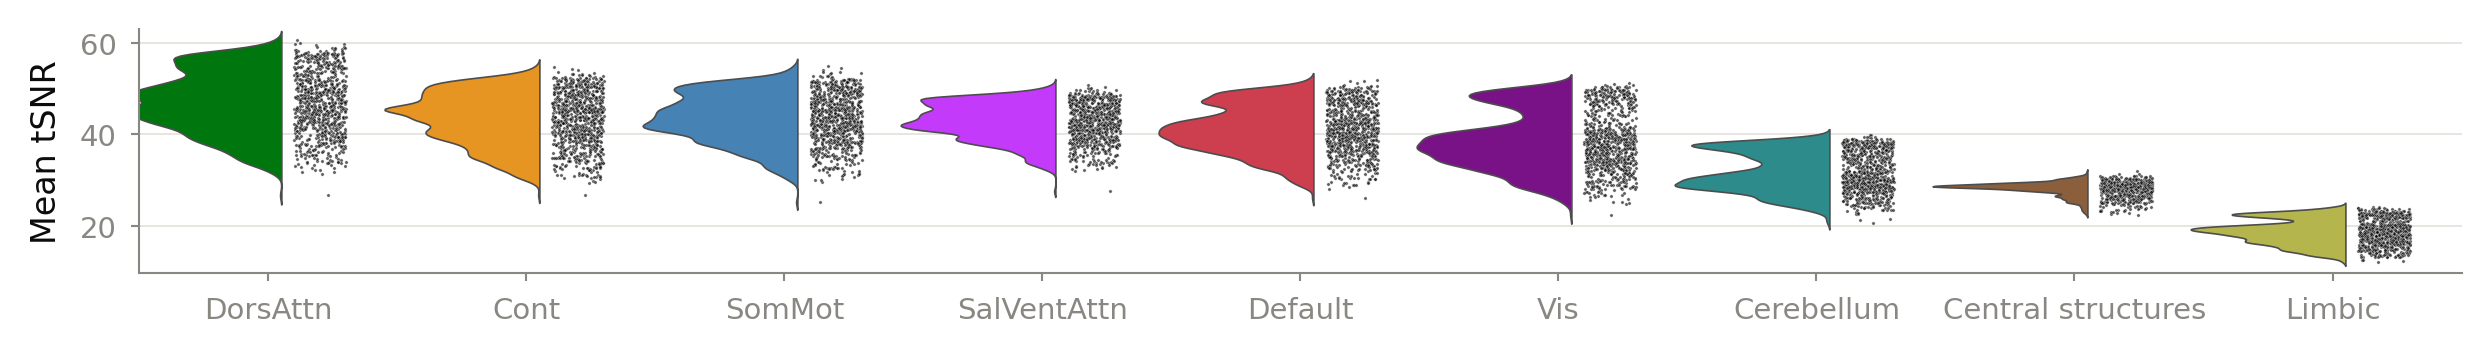

In [4]:
RUN_ID_COLS = ["dataset", "subject", "session", "task", "run"]


def category_values(regions, group_mask, category):
    """One tSNR value per run for a display category.

    `run-atlas-tsnr` already averaged each region group's parcels within a run,
    so a category backed by a single group (a cortex network, the cerebellum)
    is simply that group's rows. "Central structures" spans the three
    subcortical groups, which hold different numbers of Tian S3 subregions, so
    they are pooled by an `n_parcels`-weighted mean — that keeps every parcel
    equally weighted, which a plain mean of the three group means would not.
    """
    subset = regions[group_mask].dropna(subset=["tsnr_mean"])
    weighted = subset.assign(total=subset["tsnr_mean"] * subset["n_parcels"])
    pooled = weighted.groupby(RUN_ID_COLS, as_index=False)[["total", "n_parcels"]].sum()
    pooled["tsnr_mean"] = pooled["total"] / pooled["n_parcels"]
    pooled["category"] = category
    return pooled[["category", "tsnr_mean"]]


if not regions.empty:
    cortex_groups = sorted(regions.loc[
        regions["group"].str.startswith("cortex_", na=False), "group"
    ].unique())
    cortex_networks = [
        category_values(regions, regions["group"] == group,
                        group.removeprefix("cortex_"))
        for group in cortex_groups
    ]

    cerebellum_avg = category_values(regions, regions["group"] == "cerebellum",
                                     "Cerebellum")
    subcortex_avg = category_values(
        regions, regions["group"].str.startswith("subcortex_", na=False),
        "Central structures")

    combined = pd.concat(cortex_networks + [cerebellum_avg, subcortex_avg],
                          ignore_index=True)

    # Panel i on the montage: a page-wide, ~1.1-inch-tall strip. The nine group
    # names fit horizontally at 6 pt, and the x-axis label is dropped — the
    # groups are self-describing and the maps below repeat them.
    fig, ax = panel("tsnr_by_region_group.png", (12, 7))
    raincloud(combined, "category", "tsnr_mean", ax, ascending=False,
              palette=GROUP_COLORS)
    ax.set_xlabel("")
    # "per run" is dropped from the label: rotated, it is taller than
    # this ~1.1-inch panel and gets clipped at the page font size.
    ax.set_ylabel("Mean tSNR")
    fig.savefig(FIG_DIR / "tsnr_by_region_group.png", dpi=figure_style.PAGE_DPI)


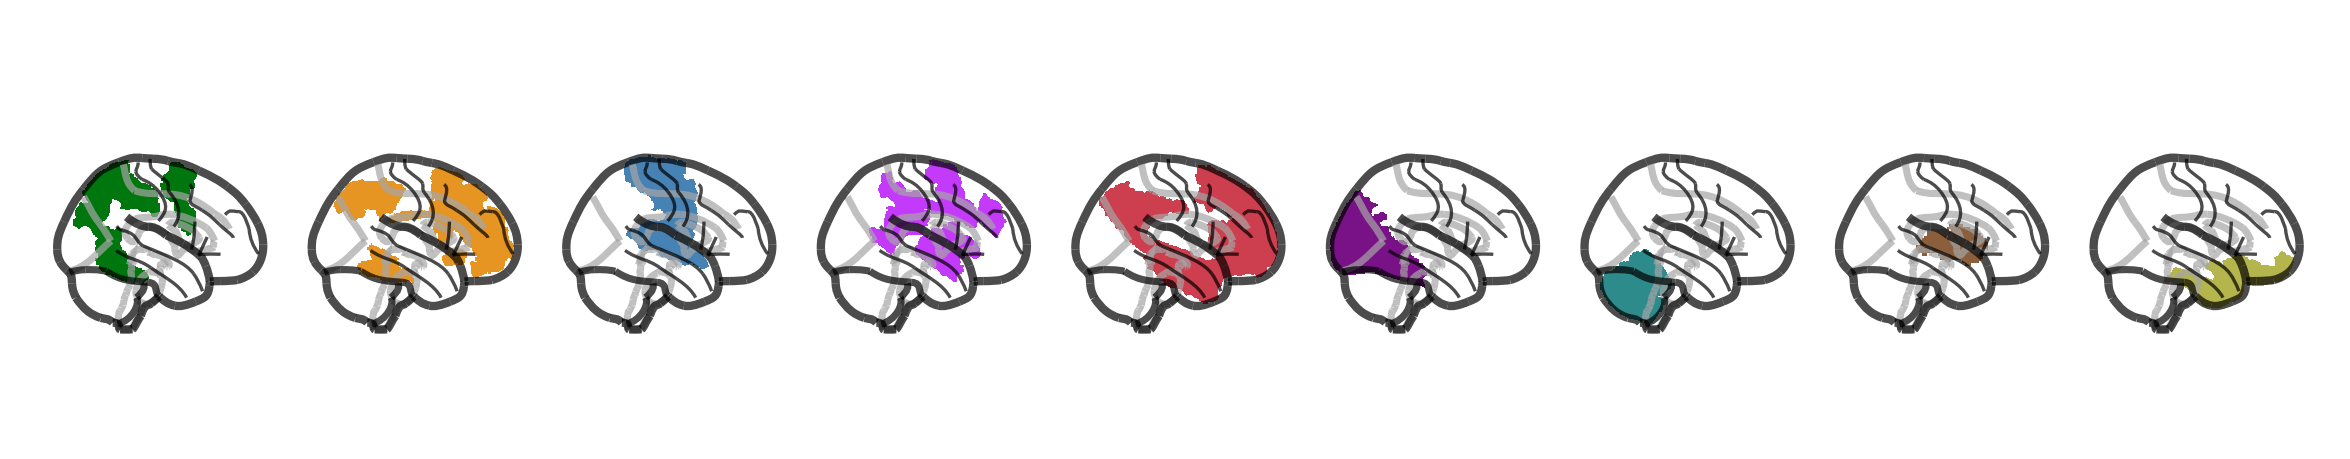

In [5]:
# --- Nine glass-brain maps: union of each region-group's parcels ----------
# Same-color-linked to the panel-i violins above (GROUP_COLORS), in the same
# worst-to-best tSNR order, laid out in a single row so map column N sits
# directly under violin N — a 1:1 positional + color link once placed under
# panel i in Inkscape. Glass brain (not `plot_roi`, no background anatomy
# needed) keeps each tile small and legible at nine-in-a-row. Sagittal
# (display_mode="x") rather than axial: it shows the dorsal/ventral extent of
# each group along the whole anterior-posterior axis, which is what separates
# the cerebellum and the central structures from the cortical networks — an
# axial projection stacks them all on top of each other.
import nibabel as nib
from matplotlib.colors import ListedColormap
from nilearn import plotting as nilearn_plotting
from nilearn.image import load_img

# `analysis` is not importable here (nbconvert runs with `notebooks/` as cwd,
# same reason tsnr_maps.ipynb duplicates its own constants), so the small bits
# of `analysis/atlas_labels.py` needed here — atlas subdir/filename layout,
# the Yeo/Tian label scheme — are duplicated locally rather than imported.
ATLAS_SPACE = "MNI152NLin2009cAsym"
ATLAS_SUBDIR = f"tpl-{ATLAS_SPACE}"
ATLAS_DESC = "Schaefer2018TianS3NettekovenAsym_desc-1000Parcels7Networks50Subcort128Cereb"
ATLAS_NII = f"tpl-{ATLAS_SPACE}_res-01_atlas-{ATLAS_DESC}_dseg.nii.gz"
ATLAS_TSV = f"tpl-{ATLAS_SPACE}_atlas-{ATLAS_DESC}.tsv"

SOURCE_DIR = Path(os.environ.get("SOURCE_DATA_DIR", "../source_data")) / "cneuromod.all"
atlases_dir = SOURCE_DIR / "anat" / "atlases"
atlas_nii_path = atlases_dir / ATLAS_SUBDIR / ATLAS_NII
atlas_tsv_path = atlases_dir / ATLAS_SUBDIR / ATLAS_TSV

if not regions.empty and atlas_nii_path.is_file() and atlas_tsv_path.is_file():
    # All 1178 labels, not just the ones present in `regions` — a local
    # equivalent of `analysis.atlas_labels.load_region_table`, re-deriving the
    # same "cortex_<Network>" / "cerebellum" / "subcortex_<PUT|THA|CAU>"
    # grouping straight from the region name (see analysis/atlas_labels.py's
    # `classify_region` docstring for the label-ID ranges this mirrors).
    YEO_NETWORKS = ("Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default")
    SUBCORTEX_STRUCTURES = ("PUT", "THA", "CAU")

    def classify_region(region_name):
        if region_name.startswith("7Networks_"):
            network = region_name.split("_")[2]
            return f"cortex_{network}" if network in YEO_NETWORKS else None
        if region_name.startswith("Cereb-"):
            return "cerebellum"
        structure = region_name.split("-")[0]
        return f"subcortex_{structure}" if structure in SUBCORTEX_STRUCTURES else None

    atlas_labels = pd.read_csv(atlas_tsv_path, sep="\t").rename(
        columns={"index": "label_id", "name": "region_name"})
    atlas_labels["group"] = atlas_labels["region_name"].map(classify_region)

    def group_label_ids(category):
        """label_id set for one of the nine display categories."""
        if category == "Cerebellum":
            mask = atlas_labels["group"] == "cerebellum"
        elif category == "Central structures":
            mask = atlas_labels["group"].str.startswith("subcortex_", na=False)
        else:
            mask = atlas_labels["group"] == f"cortex_{category}"
        return atlas_labels.loc[mask, "label_id"].tolist()

    atlas_img = load_img(str(atlas_nii_path))
    atlas_data = np.asarray(atlas_img.dataobj)

    # Same worst-to-best order as panel i's x-axis, so map column N lines up
    # with violin N (recomputed the same way `raincloud` orders categories).
    category_order = (combined.groupby("category")["tsnr_mean"].median()
                       .sort_values(ascending=False).index.tolist())

    # nilearn takes over the axes it is handed, so this panel keeps the plain
    # layout engine (not `panel()`'s constrained one) and trims its margins with
    # subplots_adjust instead — bbox_inches="tight" is off everywhere now, since
    # cropping after the fact is what made the saved size unpredictable.
    fig, axes = plt.subplots(
        1, len(category_order),
        figsize=figure_style.panel_size(f"{FIG_NAME}/network_maps.png",
                                        (2.2 * len(category_order), 3)))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0)
    for ax, category in zip(axes, category_order):
        mask = np.isin(atlas_data, group_label_ids(category))
        mask_img = nib.Nifti1Image(mask.astype(np.int8), atlas_img.affine)
        nilearn_plotting.plot_glass_brain(
            mask_img, axes=ax, display_mode="x", colorbar=False,
            cmap=ListedColormap([GROUP_COLORS[category]]), vmin=0.5, vmax=1,
            plot_abs=False,
        )
        # No per-tile title: panel i sits directly above on the page and its
        # x-axis already names each group in this same column order, so a
        # title here just prints every name twice.
    fig.savefig(FIG_DIR / "network_maps.png", dpi=figure_style.PAGE_DPI)
else:
    print("Atlas dseg/TSV not found under anat/atlases — run `invoke fetch` first "
          "(needs data access). Skipping network_maps.png.")
